<a href="https://colab.research.google.com/github/serjisa/clones2cells_app/blob/main/clones2cells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive explorer of clonal embeddings

We decided to include an interactive explorer of cells and clones in the `clone2vec` library: it fuses with the analysis pipeline naturally and requires minimal effort.

In [ ]:
!pip install clone2vec[full]

Firstly, we need to obtain two linked AnnData objects: with cells and with clones. We will use pre-built ones (from [Liu et al.](https://www.nature.com/articles/s43018-021-00292-8)).

In [3]:
import clone2vec as c2v

adata = c2v.datasets.Liu_NSCLC_CD8(embedding_type="gex")
clones = c2v.datasets.Liu_NSCLC_CD8(embedding_type="c2v")

  0%|          | 0.00/879M [00:00<?, ?B/s]

  0%|          | 0.00/2.68M [00:00<?, ?B/s]

In the viewer, you can do two operations:
1. select clones to highlight which cells are in selected clones, or
2. select cells to color clones by proportion of selected cells in them.

In [16]:
c2v.pl.clones2cells(
    adata=adata,
    clones=clones,
    cells_color="cluster", # Column in adata.obs or gene name
    clones_color="leiden", # Column in clones.obs or gene
    s_cells_bg=2, # Dot size for cells
    s_cells_selected=8, # Dot size for mapped cells
    s_clones=8, # Dot size for clones
)

GridBox(children=(VBox(children=(HTML(value='<b style="display: flex; justify-content: center; margin: 0 0 0 3…

After your work, you can export selection and plot it if you want.

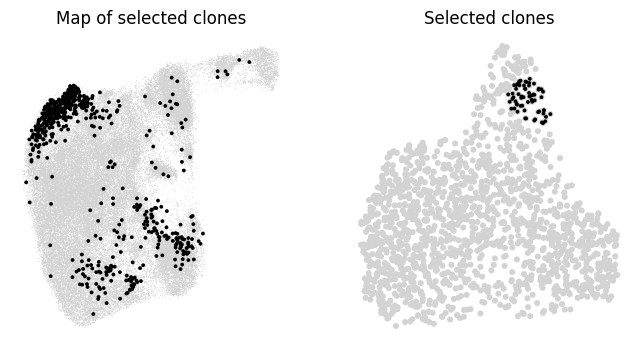

In [17]:
import matplotlib.pyplot as plt

selected_clones = clones.uns["clones2cells"]["last_selection"]
clones.obs["selection"] = [
    "Selected" if i in selected_clones else "Non-selected"
    for i in clones.obs_names
]
c2v.pp.transfer_annotation(adata, clones, annotation_obs_clones="selection")

fig, axes = plt.subplots(figsize=(8, 4), ncols=2)
c2v.pl.group_scatter(
    adata,
    groupby="c2v_selection",
    groups=["Selected"],
    ax=axes[0],
    square=False,
    title="Map of selected clones",
)
c2v.pl.group_scatter(
    clones,
    groupby="selection",
    groups="Selected",
    ax=axes[1],
    square=False,
    title="Selected clones",
)